# 🌼Quantum Phase Explorer🌼
**Question:** Can two states have the same measurement probabilities but behave differently?

An independent practice lab for one-qubit phase, basis choice, interference and the Bloch sphere.


  رح نعرف  : اذا هل ممكن حالتين يعطو نفس نسب القياس لكن نقدر نفرق بينهم اذا غيرنا طريقة القياس؟ .


.

In [1]:
# Run once if Qiskit is not installed (e.g. in Google Colab):
# %pip install qiskit==2.2.3 numpy==2.3.5 matplotlib==3.10.8 ipywidgets
import sys
import qiskit
print("Python:", sys.version.split()[0], "| Qiskit:", qiskit.__version__)


Python: 3.12.14 | Qiskit: 2.2.3


## 1. Predict before running
Starting from $|0\rangle$, apply $H$ and then $P(\varphi)=\mathrm{diag}(1,e^{i\varphi})$:

$$|\psi\rangle=\frac{|0\rangle+e^{i\varphi}|1\rangle}{\sqrt{2}}.$$

Direct Z-basis measurement gives $P(0)=P(1)=1/2$. A final Hadamard makes
$P(0)=\cos^2(\varphi/2)$ and $P(1)=\sin^2(\varphi/2)$.

توقعو: ماذا يحدث عند $\varphi=0$، ثم عند $\varphi=\pi$؟ الـHadamard الأخير وهذا يخلي القياس في أساس Z مكافئ لقياس الحالة السابقة في أساس X.

## 2. Reusable implementation
The next cell defines the experiment.

In [2]:
"""Explore relative phase with ideal one-qubit circuits and reproducible sampling."""
from pathlib import Path
import csv
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

GREEN = "#176B58"
PURPLE = "#7465A8"


def phase_circuit(phi, analyze=False):
    """Prepare H then P(phi); optionally apply H before Z-basis measurement."""
    circuit = QuantumCircuit(1)
    circuit.h(0)
    circuit.p(float(phi), 0)
    if analyze:
        circuit.h(0)
    return circuit


def phase_state(phi, analyze=False):
    return Statevector.from_instruction(phase_circuit(phi, analyze))


def bloch_coordinates(state):
    """Return <X>, <Y>, <Z> for a normalized pure one-qubit state."""
    amplitudes = np.asarray(state, dtype=complex)
    if amplitudes.shape != (2,) or not np.isclose(np.linalg.norm(amplitudes), 1):
        raise ValueError("Expected a normalized one-qubit state.")
    a, b = amplitudes
    return np.array([2 * (a.conjugate() * b).real,
                     2 * (a.conjugate() * b).imag,
                     abs(a)**2 - abs(b)**2])


def sample_counts(probabilities, shots, rng):
    """Classical draws from an ideal probability vector, not hardware measurements."""
    if not isinstance(shots, (int, np.integer)) or shots <= 0:
        raise ValueError("shots must be a positive integer")
    p = np.asarray(probabilities, dtype=float)
    if p.ndim != 1 or not np.all(np.isfinite(p)) or np.any(p < -1e-12):
        raise ValueError("Invalid probabilities")
    if not np.isclose(p.sum(), 1):
        raise ValueError("Probabilities must sum to one")
    p = np.clip(p, 0, 1)
    return rng.multinomial(shots, p / p.sum())


def run_experiment(output_dir="results/phase", shots=2048, seed=42):
    """Write CSV data, three figures and provenance; return numeric sweep records."""
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    rng = np.random.default_rng(seed)
    records = []
    for phi in np.linspace(0, 2 * np.pi, 65):
        before = phase_state(phi).probabilities()
        after = phase_state(phi, True).probabilities()
        counts = sample_counts(after, shots, rng)
        records.append({"phase_radians": float(phi),
                        "p0_before_H": float(before[0]),
                        "p0_after_H_exact": float(after[0]),
                        "p0_after_H_theory": float(np.cos(phi / 2)**2),
                        "count_0": int(counts[0]), "count_1": int(counts[1]),
                        "shots": shots, "p0_sampled": float(counts[0] / shots)})
    with (output / "phase_sweep.csv").open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(records[0]))
        writer.writeheader()
        writer.writerows(records)

    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.facecolor": "white"})
    phases = np.array([r["phase_radians"] for r in records])
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    ax.plot(phases, [r["p0_after_H_theory"] for r in records], color=GREEN,
            label=r"Theory: $\cos^2(\varphi/2)$", linewidth=2)
    ax.scatter(phases[::4], [r["p0_after_H_exact"] for r in records[::4]],
               facecolors="none", edgecolors="black", s=46, label="Exact statevector")
    ax.scatter(phases, [r["p0_sampled"] for r in records], color=PURPLE,
               s=13, alpha=.7, label=f"Sampled: {shots:,} shots / phase")
    ax.axhline(.5, color="#888888", linestyle="--", label="Without final H")
    ax.set(xticks=np.linspace(0, 2*np.pi, 5),
           xticklabels=["0", "π/2", "π", "3π/2", "2π"], ylim=(-.04, 1.04),
           xlabel="Relative phase φ (radians)", ylabel="Probability of outcome 0",
           title="A final Hadamard turns relative phase into observable interference")
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(.5, -.18), ncol=2)
    fig.savefig(output / "phase_interference.png", dpi=170)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    x = np.arange(2)
    for ax, analyze in zip(axes, [False, True]):
        for offset, phi, label, color in [(-.18, 0, r"$|+\rangle$ (φ = 0)", GREEN),
                                          (.18, np.pi, r"$|-\rangle$ (φ = π)", PURPLE)]:
            ax.bar(x + offset, phase_state(phi, analyze).probabilities(),
                   width=.36, label=label, color=color)
        ax.set(xticks=x, xticklabels=["0", "1"], ylim=(0, 1.16),
               xlabel="Measurement outcome", ylabel="Exact probability",
               title="Final H, then Z measurement" if analyze else "Direct Z measurement")
        ax.legend(fontsize=9)
    fig.savefig(output / "plus_minus_comparison.png", dpi=170)
    plt.close(fig)

    fig = plt.figure(figsize=(8, 6), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    u = np.linspace(0, 2*np.pi, 36)
    v = np.linspace(0, np.pi, 18)
    ax.plot_wireframe(np.outer(np.cos(u), np.sin(v)),
                      np.outer(np.sin(u), np.sin(v)),
                      np.outer(np.ones_like(u), np.cos(v)),
                      color="#D4DDD8", linewidth=.4, alpha=.6)
    ax.plot(np.cos(u), np.sin(u), 0*u, color=GREEN, alpha=.5)
    for phi, label, color in [(0, "φ=0", GREEN), (np.pi/2, "φ=π/2", "#BE9150"),
                               (np.pi, "φ=π", PURPLE), (3*np.pi/2, "φ=3π/2", "#537EAA")]:
        point = bloch_coordinates(phase_state(phi))
        ax.quiver(0, 0, 0, *point, color=color, linewidth=2, arrow_length_ratio=.12)
        ax.text(*(1.16*point), label, color=color)
    ax.set(xlabel="X", ylabel="Y", zlabel="Z", xlim=(-1.3, 1.3),
           ylim=(-1.3, 1.3), zlim=(-1.1, 1.1),
           title="Relative phase rotates the state around the Bloch equator")
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=24, azim=40)
    fig.savefig(output / "bloch_phase.png", dpi=170)
    plt.close(fig)

    error = max(abs(r["p0_after_H_exact"] - r["p0_after_H_theory"]) for r in records)
    metadata = {"experiment": "Quantum Phase Explorer", "shots_per_phase": shots,
                "seed": seed, "phase_points": len(records), "python": platform.python_version(),
                "qiskit": qiskit.__version__, "numpy": np.__version__,
                "max_absolute_theory_error": error,
                "backend": "Ideal Qiskit Statevector; NumPy multinomial sampling",
                "hardware_run": False}
    (output / "metadata.json").write_text(json.dumps(metadata, indent=2)+"\n", encoding="utf-8")
    return records




In [3]:
print(phase_circuit(np.pi / 2, analyze=True).draw(output="text"))
print("Before final H:", np.round(phase_state(np.pi / 2).data, 4))
print("After final H, probabilities:", np.round(phase_state(np.pi / 2, True).probabilities(), 4))

   ┌───┐┌────────┐┌───┐
q: ┤ H ├┤ P(π/2) ├┤ H ├
   └───┘└────────┘└───┘
Before final H: [0.7071+0.j     0.    +0.7071j]
After final H, probabilities: [0.5 0.5]


## 3. Run a full phase sweep
Each setting is sampled 2,048 times from its ideal probability distribution. The random seed makes this run reproducible. Finite-shot variation is not a model of device noise.

Settings: 65 | maximum exact–theory difference: 6.66e-16


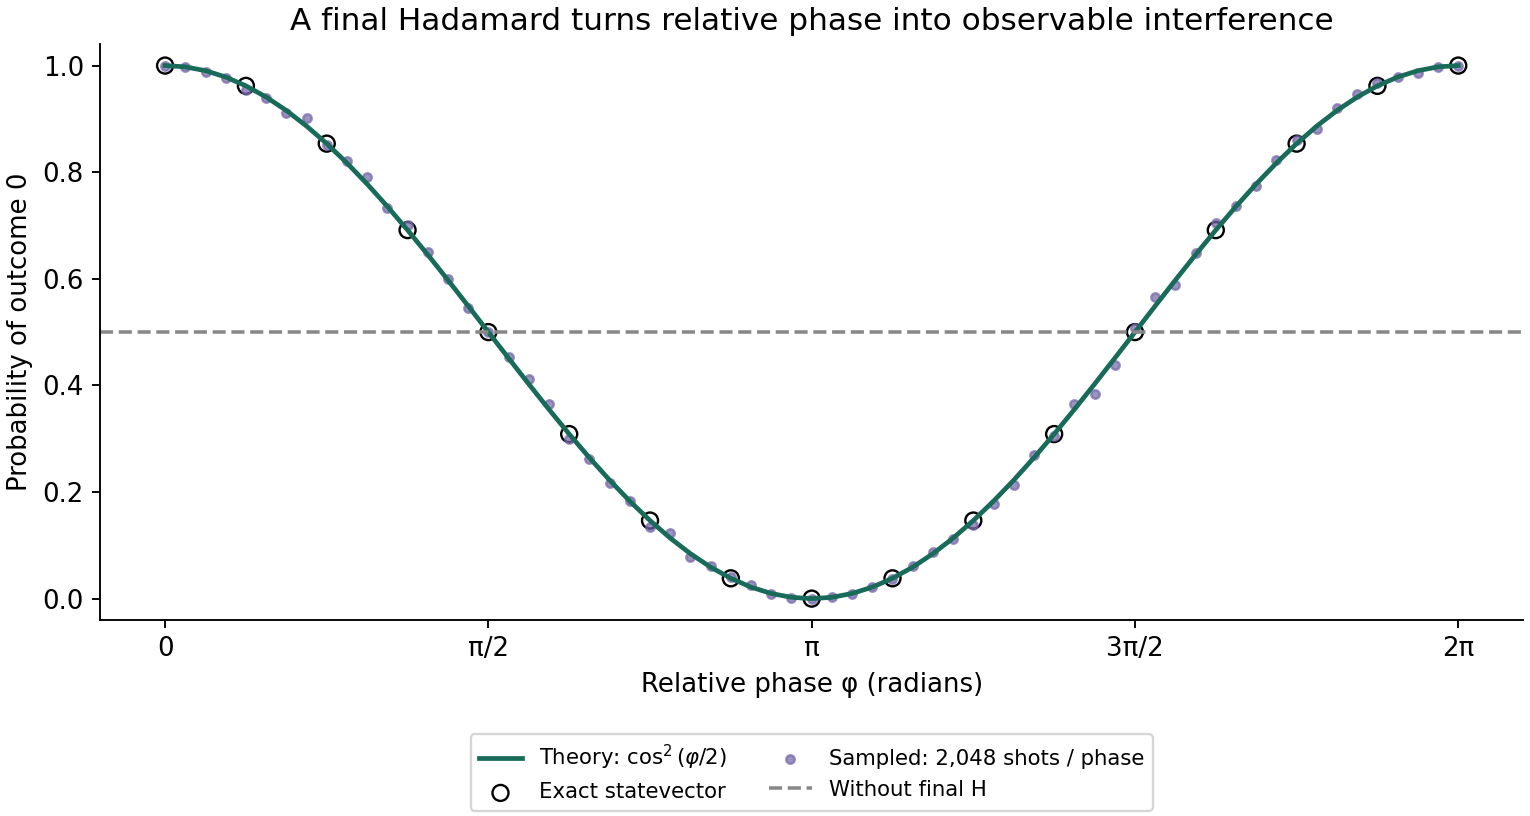

In [4]:
records = run_experiment(shots=2048, seed=42)
max_error = max(abs(r["p0_after_H_exact"] - r["p0_after_H_theory"]) for r in records)
print(f"Settings: {len(records)} | maximum exact–theory difference: {max_error:.2e}")
from IPython.display import Image, display
display(Image(filename="results/phase/phase_interference.png"))

## 4. Compare $|+\rangle$ and $|-\rangle$
Both states produce 50/50 outcomes when measured directly in Z. After a Hadamard, $|+\rangle$ becomes $|0\rangle$ and $|-\rangle$ becomes $|1\rangle$.

الخلاصة هنا ان : نسب القياس في أساس واحد لا تصف الحالة الكمية بالكامل. اختلاف الطور النسبي ممكن يظهر لما نغير أساس القياس.

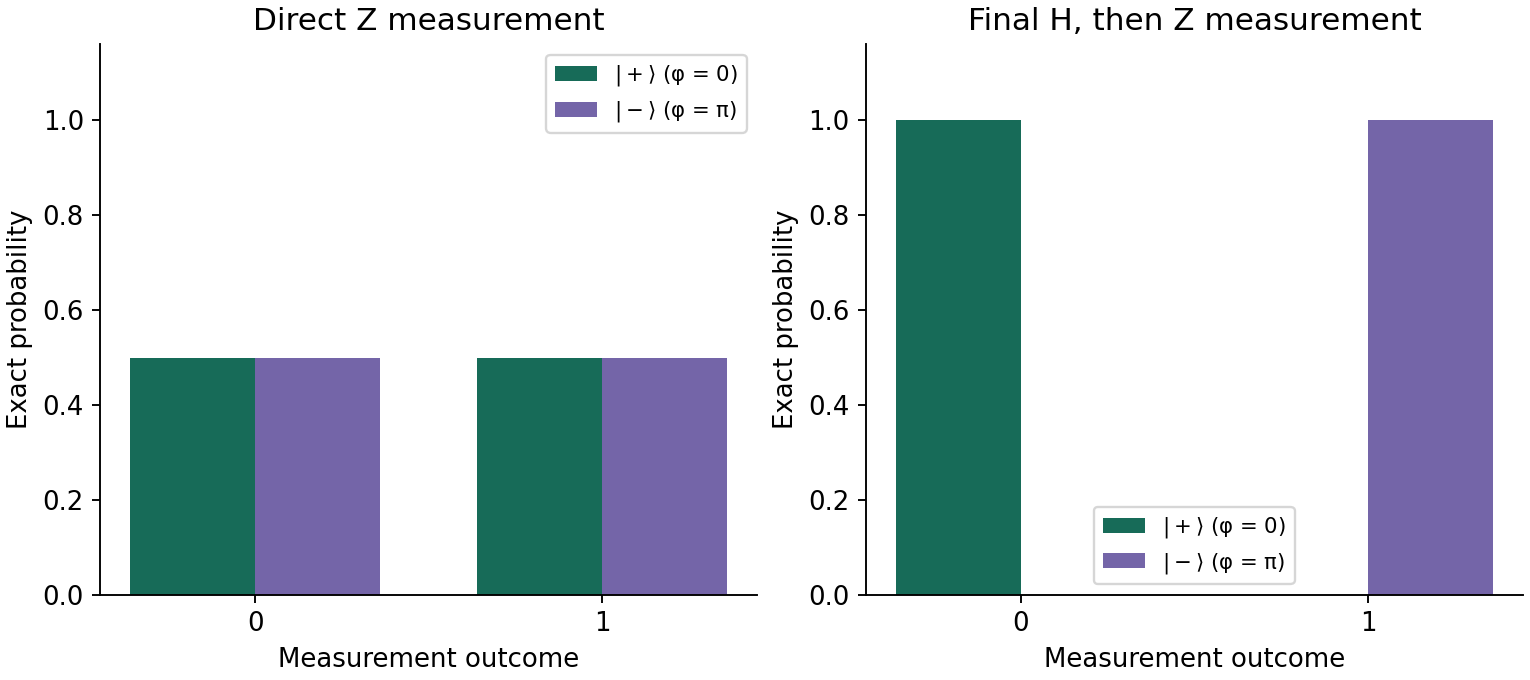

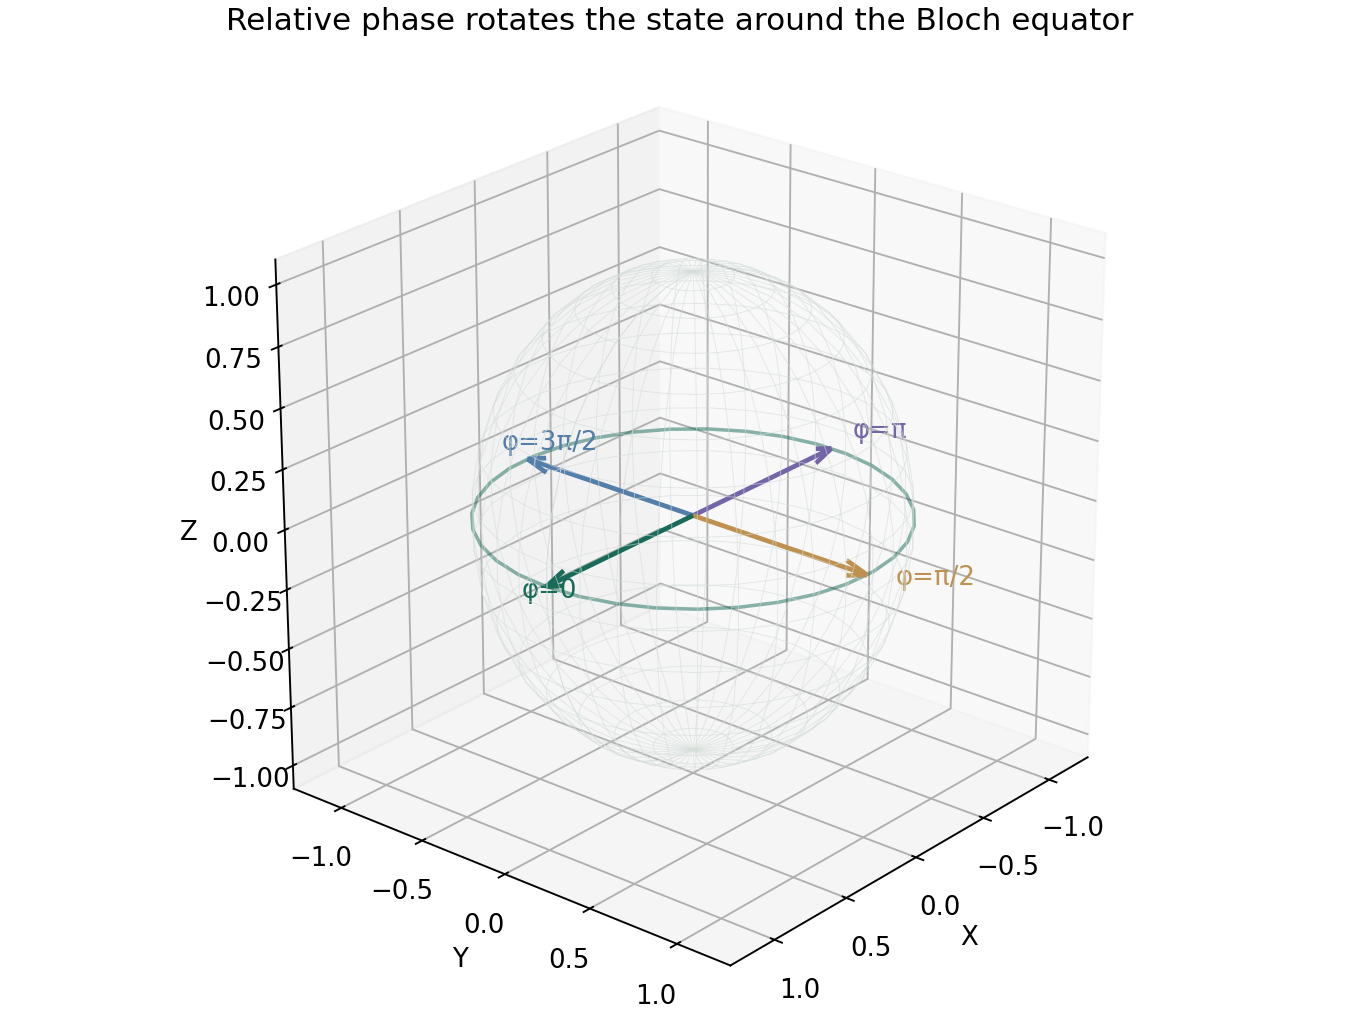

In [5]:
display(Image(filename="results/phase/plus_minus_comparison.png"))
display(Image(filename="results/phase/bloch_phase.png"))

## 5. Global phase is different
Multiplying the **entire** state by $e^{i\gamma}$ does not change observable probabilities. Relative phase changes one amplitude relative to another. For a pure qubit, the Bloch coordinates are $(2\Re(a^*b),2\Im(a^*b),|a|^2-|b|^2)$.

ضرب الحالة كلها بنفس عامل الطور يختلف عن تغيير الطور بين جزأين الحاله

In [6]:
state = phase_state(np.pi / 3)
global_phase_state = Statevector(np.exp(1j * 0.73) * state.data)
analyzer = QuantumCircuit(1)
analyzer.h(0)
print("Original:", np.round(state.evolve(analyzer).probabilities(), 6))
print("With global phase:", np.round(global_phase_state.evolve(analyzer).probabilities(), 6))
assert np.allclose(state.evolve(analyzer).probabilities(),
                   global_phase_state.evolve(analyzer).probabilities())

Original: [0.75 0.25]
With global phase: [0.75 0.25]


## 6. Change the phase yourself
.

In [7]:
PHI = np.pi / 3
print("φ =", PHI)
print("Bloch coordinates:", np.round(bloch_coordinates(phase_state(PHI).data), 4))
print("P(0), P(1) after H:", np.round(phase_state(PHI, True).probabilities(), 4))

φ = 1.0471975511965976
Bloch coordinates: [0.5   0.866 0.   ]
P(0), P(1) after H: [0.75 0.25]


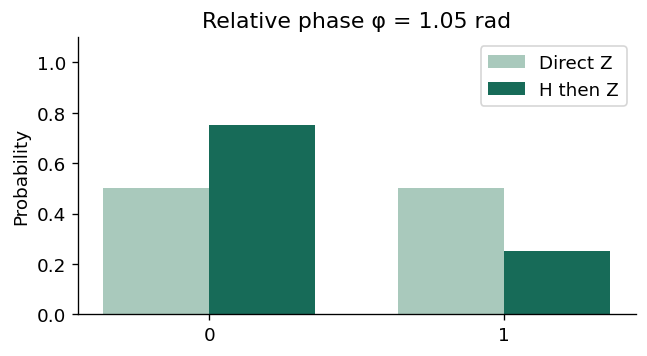

In [8]:
def explore_phase(phi):
    before = phase_state(phi).probabilities()
    after = phase_state(phi, True).probabilities()
    fig, ax = plt.subplots(figsize=(6, 3))
    x = np.arange(2)
    ax.bar(x - .18, before, width=.36, label="Direct Z", color="#A9C9BC")
    ax.bar(x + .18, after, width=.36, label="H then Z", color="#176B58")
    ax.set(xticks=x, xticklabels=["0", "1"], ylim=(0, 1.1), ylabel="Probability",
           title=f"Relative phase φ = {phi:.2f} rad")
    ax.legend()
    from io import BytesIO
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

try:
    import os
    if os.environ.get("QUANTUM_LABS_STATIC_RUN") == "1":
        raise ImportError("Static execution: show the default experiment")
    from ipywidgets import interact, FloatSlider
    interact(explore_phase, phi=FloatSlider(value=0, min=0, max=2*np.pi,
             step=np.pi/24, description="Phase φ", continuous_update=False))
except ImportError:
    explore_phase(PHI)


.

**Sources:** [IBM: global and relative phase](https://quantum.cloud.ibm.com/learning/en/courses/basics-of-quantum-information/quantum-circuits/limitations-on-quantum-information), [Qiskit Statevector](https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.2/qiskit.quantum_info.Statevector).
